In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import scanpy as sc
import decoupler as dc
import pandas as pd

In [4]:
sc.settings.set_figure_params(dpi=100, frameon=False)
sc.settings.verbosity = 2

In [5]:
adata = sc.read_h5ad("data/oren_non_cycling.h5ad")
adata.var_names_make_unique()

In [6]:
adata.layers["counts"] = adata.X.copy()

In [7]:
sc.pp.filter_genes(adata, min_cells=20)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="cell_line", flavor="cell_ranger")

filtered out 5715 genes that are detected in less than 20 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:02)


computing PCA
    with n_comps=50
    finished (0:00:03)


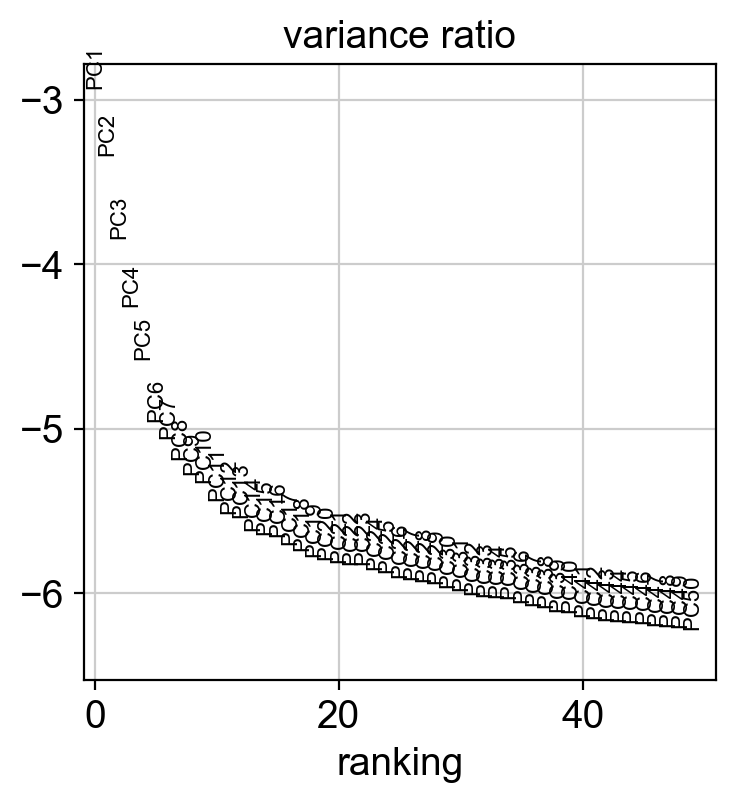

In [8]:
sc.pp.pca(adata, use_highly_variable=True)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished (0:00:34)
computing UMAP
    finished (0:00:42)


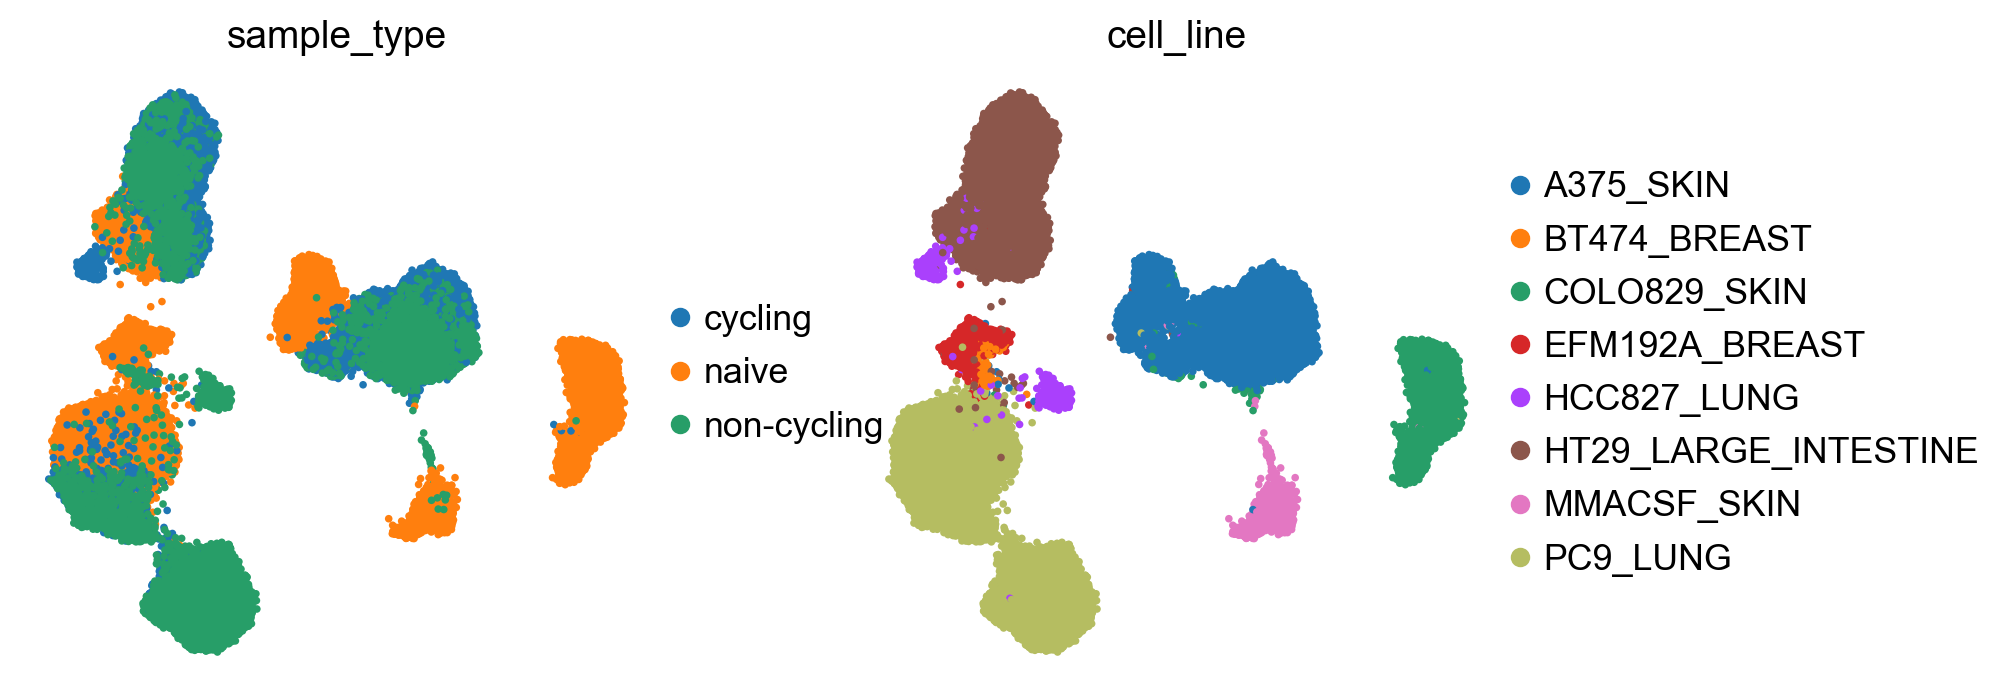

In [9]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color=["sample_type", "cell_line"], s=30)

In [10]:
# up genes in non-cycling, then up genes in cycling
sc.tl.rank_genes_groups(
    adata,
    groupby="sample_type",
    groups=["non-cycling"],
    reference="naive",
    method="wilcoxon",
)

ranking genes
    finished (0:01:20)


In [11]:
markers = sc.get.rank_genes_groups_df(adata, group="non-cycling")

In [12]:
# Upregulated / downregulated
upregulated_genes = markers.query("logfoldchanges > 2 and pvals_adj < 0.01")["names"].tolist()
downregulated_genes = markers.query("logfoldchanges < -2 and pvals_adj < 0.01")["names"].tolist()
print(f"Upregulated genes: {len(upregulated_genes)}")
print(f"Downregulated genes: {len(downregulated_genes)}")

Upregulated genes: 158
Downregulated genes: 115


In [13]:
def quiescence_score(
    adata,
    up_genes: list,
    down_genes: list,
    layer: str | None = None,
    key_added: str = "quiescence_score",
):
    """Calculate quiescence scores from an AnnData object (genes in var, cells in obs).

    Parameters
    ----------
    adata : AnnData
        AnnData object containing expression matrix (adata.X or adata.layers[layer]).
    up_genes : list of str
        Genes upregulated in quiescent cells.
    down_genes : list of str
        Genes downregulated in quiescent cells.
    layer : str or None, optional (default: None)
        Layer in `adata.layers` to use instead of `adata.X`.
    key_added : str, optional (default: "quiescence_score")
        Key under which to store the resulting scores in `adata.obs`.

    Returns
    -------
    pd.Series
        Quiescence score per cell (also stored in `adata.obs[key_added]`).
    """
    import numpy as np
    import pandas as pd
    from scipy.stats import zscore

    # Select expression matrix
    if layer is None:
        X = adata.X
    else:
        if layer not in adata.layers:
            raise ValueError(f"Layer '{layer}' not found in adata.layers.")
        X = adata.layers[layer]

    # Ensure dense
    if not isinstance(X, np.ndarray):
        X = X.toarray()

    expr_df = pd.DataFrame(X.T, index=adata.var_names, columns=adata.obs_names)

    # Filter gene sets for intersection with available genes
    up_genes = [g for g in up_genes if g in expr_df.index]
    down_genes = [g for g in down_genes if g in expr_df.index]

    if not up_genes or not down_genes:
        raise ValueError("No overlap between signature genes and adata.var_names.")

    # Z-score per gene across cells
    expr_z = pd.DataFrame(
        zscore(expr_df.values, axis=1, nan_policy="omit"),
        index=expr_df.index,
        columns=expr_df.columns,
    )

    # Compute gene set means scaled by sqrt(gene count)
    up_score = expr_z.loc[up_genes].sum(axis=0) / np.sqrt(len(up_genes))
    down_score = expr_z.loc[down_genes].sum(axis=0) / np.sqrt(len(down_genes))
    score = up_score - down_score
    score.name = key_added

    # Store in adata.obs
    adata.obs[key_added] = score

In [14]:
quiescence_score(adata, upregulated_genes, downregulated_genes, key_added="oren_quiescence")

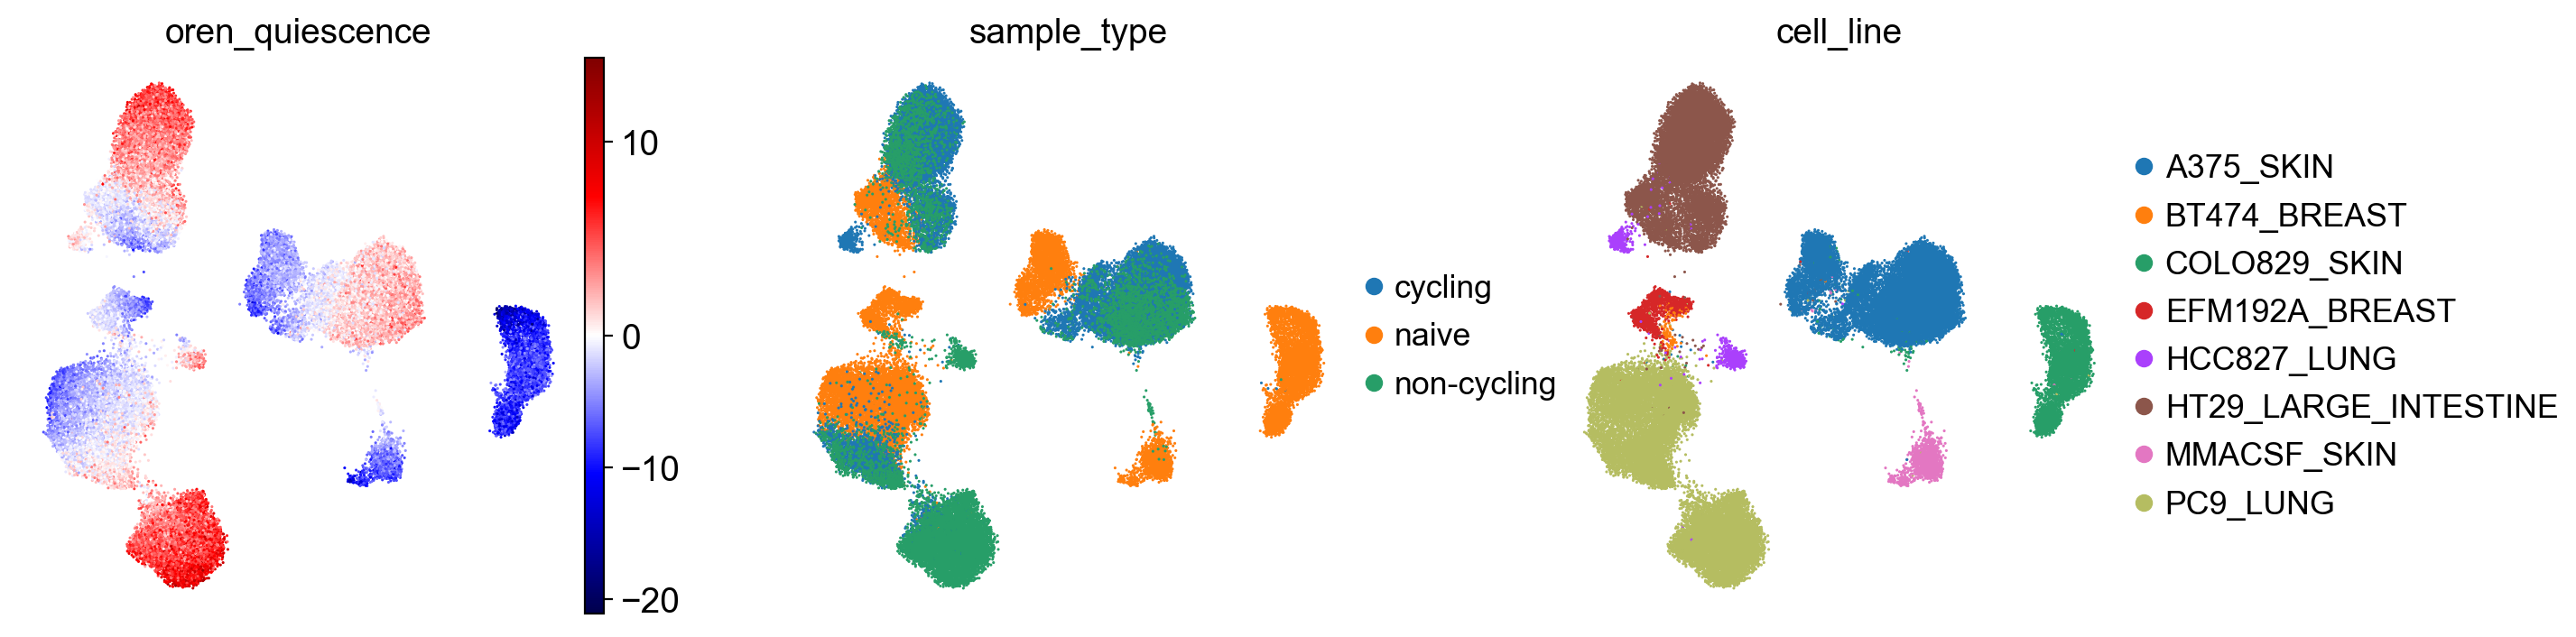

In [15]:
sc.pl.umap(
    adata,
    color=["oren_quiescence", "sample_type", "cell_line"],
    color_map="seismic",
    vcenter=0,
    s=5,
    sort_order=False,
    wspace=0.25,
)

In [16]:
gene_sets = {
    "upregulated": upregulated_genes,
    "downregulated": downregulated_genes,
}

In [17]:
import pickle

with open("gene_sets.pkl", "wb") as f:
    pickle.dump(gene_sets, f)